# Song Lyrics Genre Classification — 01 Exploratory Data Analysis

A **text-classification** project that predicts a song's genre (rap, pop, rock, r&b) from its lyrics. **Multi-class** classification — 4 genres.

We use a TF-IDF + classic-ML pipeline: this notebook explores the raw text and labels.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
%matplotlib inline
import utils

df=utils.load_data()
print('rows:',len(df),'| classes:',df['label'].nunique())
df.head(3)

rows: 6000 | classes: 4


,text,label
0,"[Intro] Keepin' it jiggy Bogle, John, Sadiki! ...",pop
1,[Intro: Timbaland] Frk-frk-down Hey You don't ...,rb
2,[Chorus: Smokey Robinson sample] If only you c...,rap


## 1. Class distribution

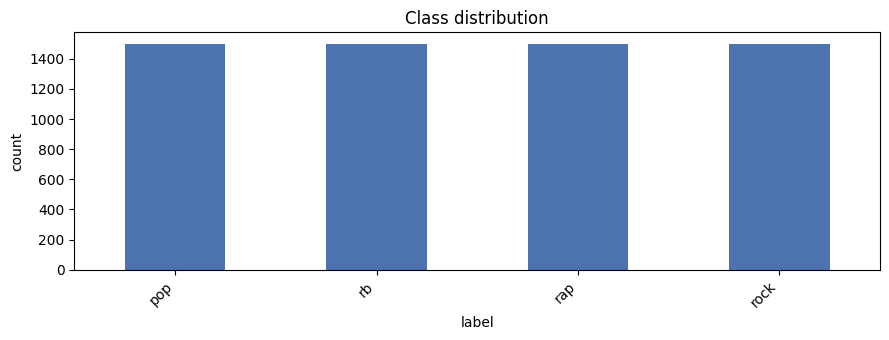

label
pop     1500
rb      1500
rap     1500
rock    1500


In [2]:
fig,ax=plt.subplots(figsize=(9,3.5))
vc=df['label'].value_counts()
vc.plot(kind='bar',ax=ax,color='#4c72b0'); ax.set_title('Class distribution'); ax.set_ylabel('count')
plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 2. Text length distribution

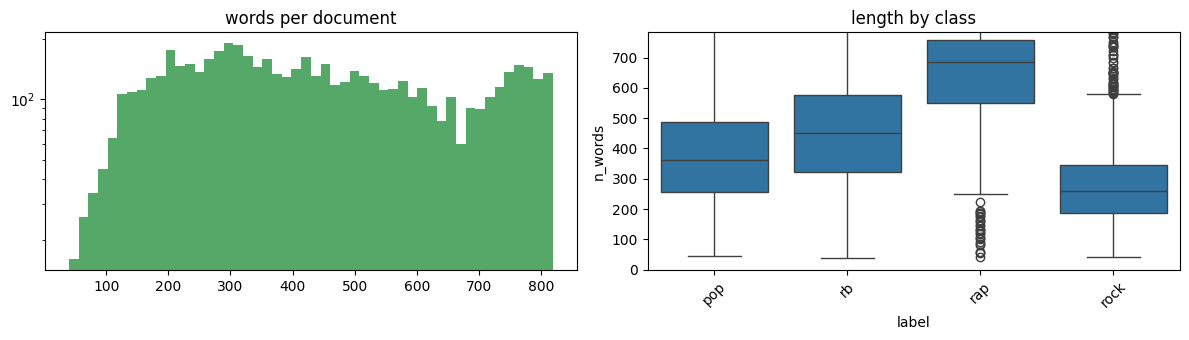

words per doc — median 418, max 933


In [3]:
df['n_words']=df['text'].astype(str).str.split().apply(len)
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(df['n_words'].clip(upper=df['n_words'].quantile(0.99)),bins=50,color='#55a868'); ax[0].set_title('words per document'); ax[0].set_yscale('log')
sns.boxplot(x='label',y='n_words',data=df,ax=ax[1]); ax[1].set_ylim(0,df['n_words'].quantile(0.95)); ax[1].set_title('length by class'); ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.show()
print('words per doc — median %d, max %d'%(df['n_words'].median(),df['n_words'].max()))

## 3. Most frequent words (raw)

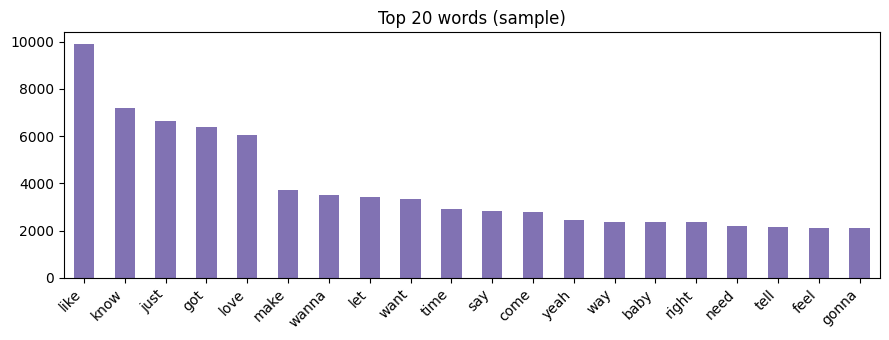

In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
words=Counter()
for t in df['text'].astype(str).head(3000):
    words.update(w for w in t.lower().split() if w.isalpha() and w not in ENGLISH_STOP_WORDS and len(w)>2)
top=pd.Series(dict(words.most_common(20)))
fig,ax=plt.subplots(figsize=(9,3.5)); top.plot(kind='bar',ax=ax,color='#8172b3'); ax.set_title('Top 20 words (sample)'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

## 4. Sample documents per class

In [5]:
for lab in df['label'].unique()[:6]:
    s=df[df['label']==lab]['text'].iloc[0]
    print(f'[{lab}] '+str(s)[:160].replace(chr(10),' ')+'...\n')

[pop] [Intro] Keepin' it jiggy Bogle, John, Sadiki! 2004, it's gonna be jiggy!  [Hook] What a Weddi, Weddi, Weddi, Weddi (March out! March out!) Weddi, Weddi, Weddi, ...

[rb] [Intro: Timbaland] Frk-frk-down Hey You don't mean nothin' at all to me Hey, hey  [Verse 1: Nelly Furtado] In the day, in the night Say it right, say it all You...

[rap] [Chorus: Smokey Robinson sample] If only you could let me in I know that love it would begin If only I could rap to you I know this love would capture you, yeah...

[rock] [Verse 1] My eyes have once again been proven wrong Your clouds, your blanket and my pity song Hovering on your front lawn Carry on until it's gone  [Chorus] Wh...



## 5. Summary

The raw text and class balance above motivate the cleaning (notebook 02) and the TF-IDF + classic-ML modelling (notebook 03). Text length and vocabulary vary by class, which is exactly the signal the classifiers will exploit.